In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import warnings 

warnings.filterwarnings('ignore')


In [2]:
df=pd.read_csv('svm_practice_dataset.csv')
df

,Feature1,Feature2,Feature3,Feature4,Target
0,-7.089981,-6.400928,-8.405856,7.928668,1
1,-3.237002,9.561371,4.088970,1.139649,0
2,-7.798972,-8.233785,-8.466454,5.795220,1
3,-7.666452,-7.162963,-9.965684,8.666617,1
4,-7.400275,-4.813523,-9.758809,6.598917,1
...,...,...,...,...,...
2495,-2.728673,10.664138,3.864722,1.014139,0
2496,1.422959,4.964354,-7.345430,8.493039,2
2497,2.960733,3.067511,-9.612212,9.100741,2
2498,3.661968,3.276168,-8.764429,10.287486,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  2500 non-null   float64
 1   Feature2  2500 non-null   float64
 2   Feature3  2500 non-null   float64
 3   Feature4  2500 non-null   float64
 4   Target    2500 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 97.8 KB


In [4]:
df.describe()

,Feature1,Feature2,Feature3,Feature4,Target
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,-2.439511,2.080141,-4.620148,6.250566,0.999600
std,3.801035,6.825714,6.666635,3.343471,0.816741
min,-9.764030,-10.684620,-14.295190,-1.616193,0.000000
25%,-6.019628,-6.185354,-9.634933,2.821625,0.000000
50%,-2.479433,4.113132,-8.431109,7.250898,1.000000
75%,1.177821,8.245975,3.859254,8.930077,2.000000
max,6.075160,13.637564,8.334536,13.633063,2.000000


In [5]:
df.duplicated().sum()

np.int64(0)

<Axes: >

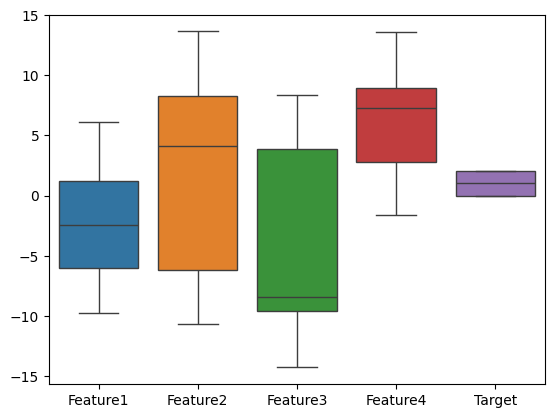

In [6]:
sns.boxplot(df)

In [7]:
df.columns

Index(['Feature1', 'Feature2', 'Feature3', 'Feature4', 'Target'], dtype='object')

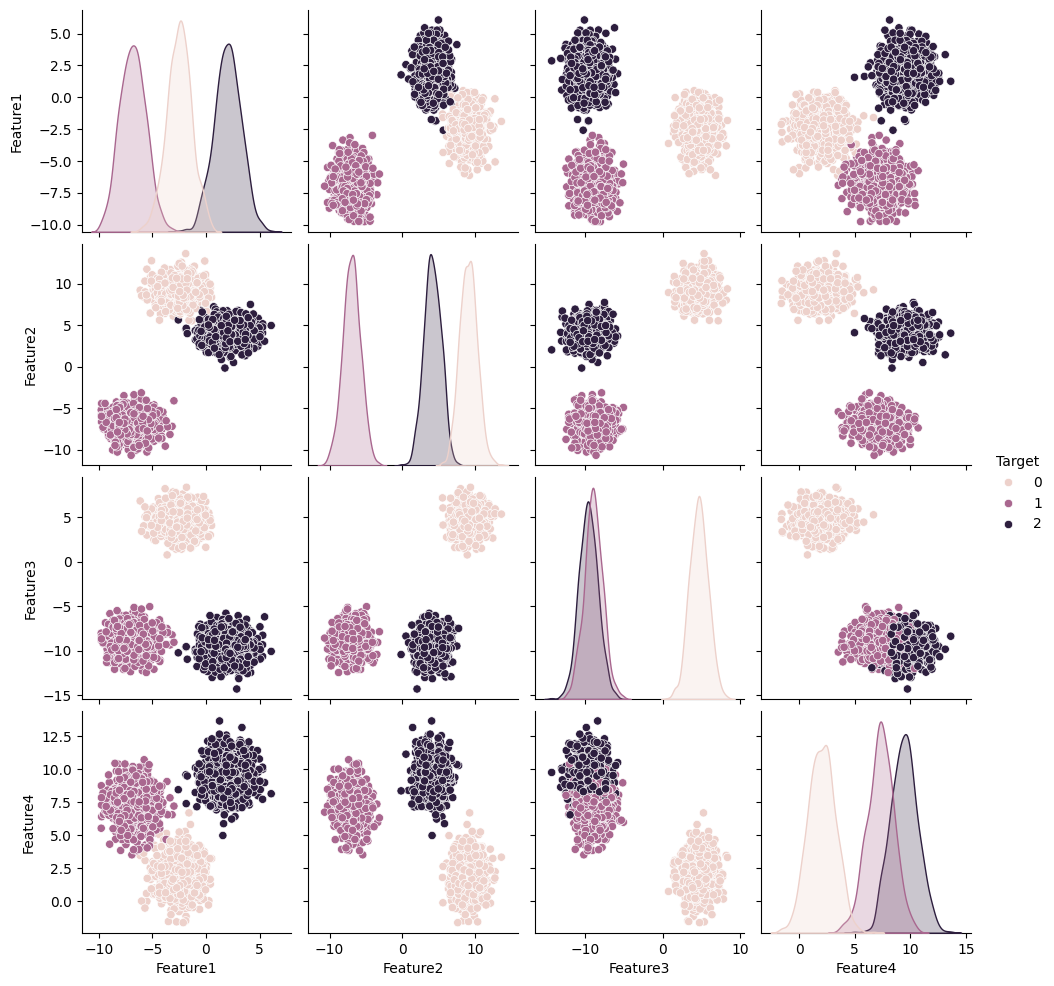

In [8]:
sns.pairplot(df,
vars=['Feature1', 'Feature2', 'Feature3', 'Feature4'],
hue='Target')

In [9]:
x=df.drop('Target',axis=1)
y=df[['Target']]
x.head()

,Feature1,Feature2,Feature3,Feature4
0,-7.089981,-6.400928,-8.405856,7.928668
1,-3.237002,9.561371,4.088970,1.139649
2,-7.798972,-8.233785,-8.466454,5.795220
3,-7.666452,-7.162963,-9.965684,8.666617
4,-7.400275,-4.813523,-9.758809,6.598917


In [10]:
y.head()

,Target
0,1
1,0
2,1
3,1
4,1


In [11]:
y.nunique()

Target    3
dtype: int64

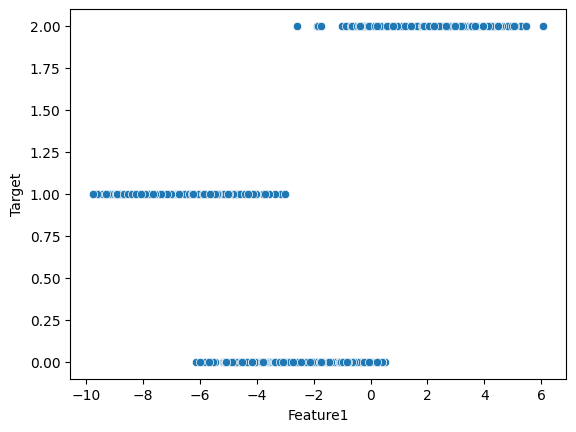

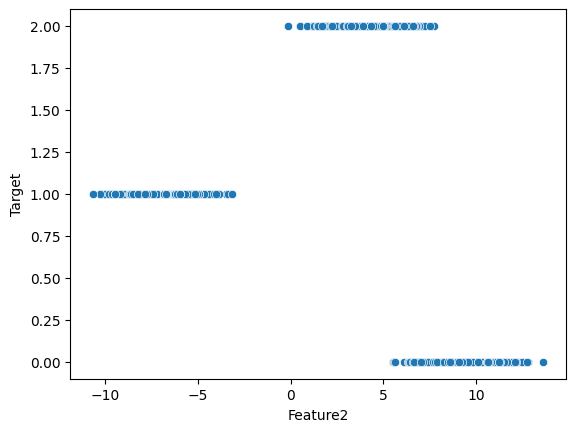

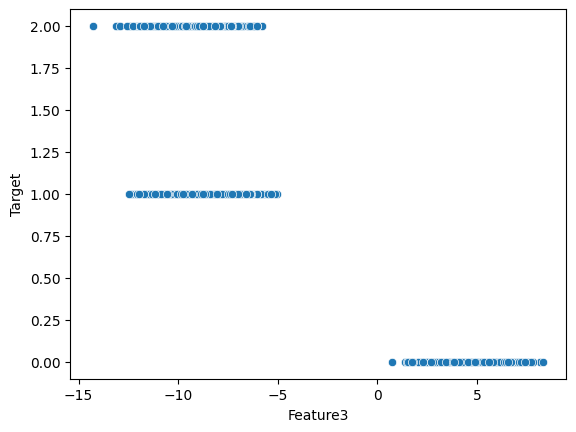

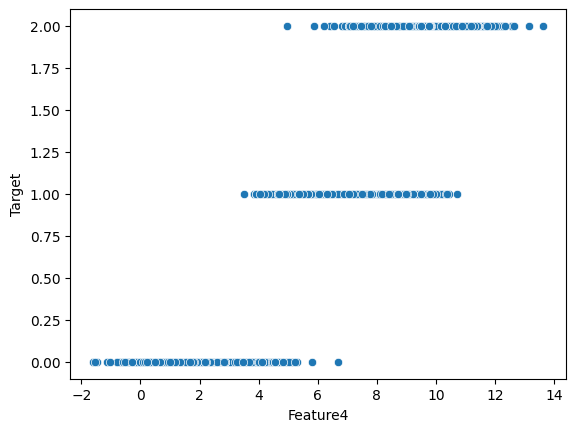

In [12]:
for i in x:
    sns.scatterplot(x=x[i],y='Target',data=df)
    plt.show()

<Axes: xlabel='Target', ylabel='count'>

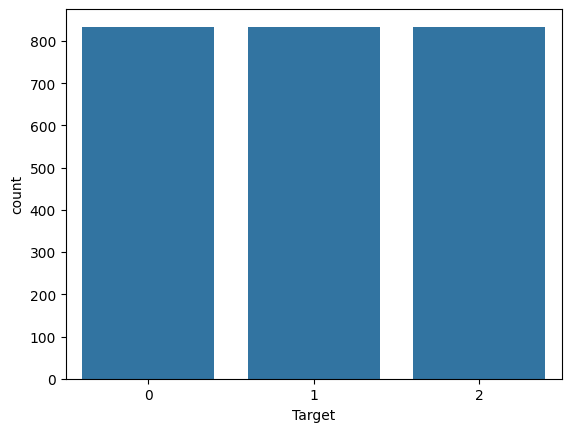

In [13]:
sns.countplot(x=y['Target'])

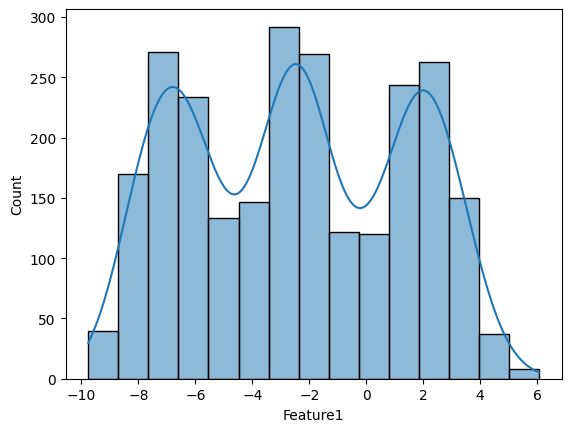

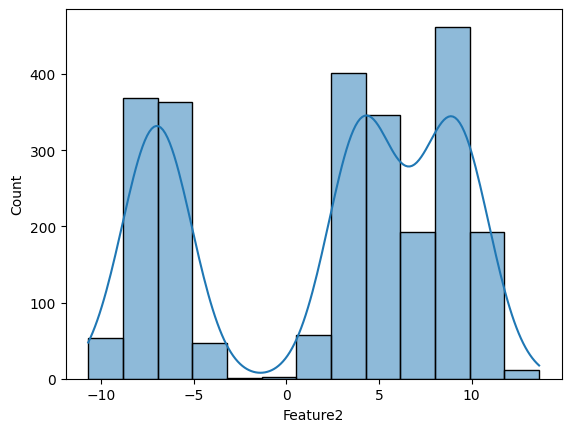

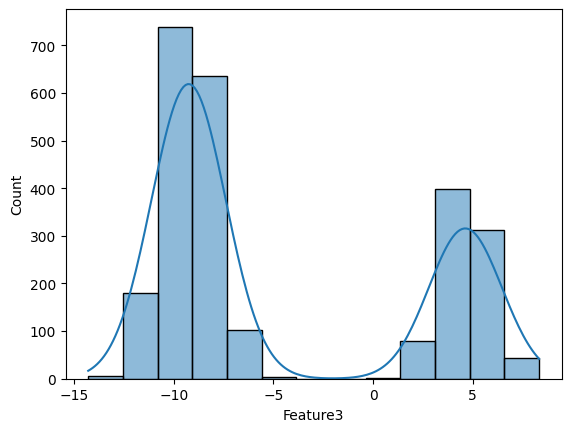

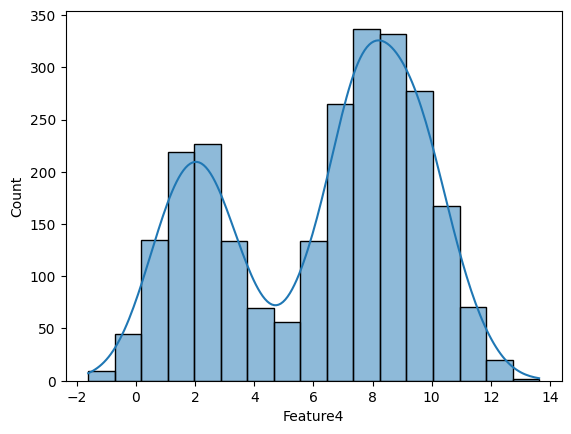

In [14]:
for i in x:
    sns.histplot(x[i],kde=True)
    plt.show()

In [15]:
x_temp=x.columns
x_temp

Index(['Feature1', 'Feature2', 'Feature3', 'Feature4'], dtype='object')

In [16]:
from sklearn.preprocessing import StandardScaler
mnmx=StandardScaler()
x=mnmx.fit_transform(x)
x=pd.DataFrame(x,columns=mnmx.get_feature_names_out(x_temp))
x

,Feature1,Feature2,Feature3,Feature4
0,-1.223719,-1.242766,-0.567973,0.502005
1,-0.209851,1.096256,1.306635,-1.528932
2,-1.410283,-1.511342,-0.577064,-0.136217
3,-1.375412,-1.354430,-0.801995,0.722762
4,-1.305370,-1.010157,-0.770957,0.104209
...,...,...,...,...
2495,-0.076090,1.257849,1.272991,-1.566478
2496,1.016366,0.422636,-0.408876,0.670836
2497,1.421014,0.144683,-0.748963,0.852631
2498,1.605536,0.175259,-0.621770,1.207646


In [17]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [18]:
model = SVC(kernel='rbf', C=1.0, gamma='scale', decision_function_shape='ovr')
model.fit(x_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [19]:
ypred=model.predict(x_test)
ypred

array([1, 1, 0, 2, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 2, 1, 2, 2, 1, 2, 0, 0,
       0, 0, 0, 2, 2, 2, 0, 0, 1, 1, 0, 1, 2, 2, 1, 0, 2, 1, 2, 1, 1, 2,
       2, 0, 2, 2, 0, 0, 0, 1, 1, 2, 0, 1, 0, 1, 2, 1, 1, 0, 2, 1, 2, 0,
       0, 0, 2, 2, 2, 2, 2, 0, 2, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 2, 0, 2,
       1, 1, 0, 1, 2, 1, 2, 1, 2, 0, 1, 1, 0, 1, 2, 1, 0, 2, 0, 0, 1, 0,
       1, 1, 2, 1, 1, 0, 2, 2, 2, 2, 0, 1, 0, 2, 0, 2, 0, 1, 0, 1, 0, 0,
       2, 1, 2, 2, 1, 2, 2, 1, 2, 2, 0, 2, 1, 2, 2, 1, 0, 2, 2, 1, 0, 1,
       1, 0, 0, 1, 2, 0, 0, 1, 0, 0, 1, 2, 2, 2, 1, 0, 0, 0, 0, 0, 2, 2,
       0, 2, 0, 2, 2, 1, 2, 2, 0, 0, 2, 1, 2, 0, 0, 2, 1, 2, 0, 2, 1, 2,
       2, 0, 2, 2, 0, 0, 2, 1, 2, 0, 1, 2, 0, 1, 0, 1, 2, 2, 0, 1, 1, 2,
       2, 2, 1, 0, 1, 0, 0, 2, 0, 0, 0, 2, 1, 0, 0, 1, 1, 2, 1, 1, 0, 1,
       1, 1, 2, 1, 0, 1, 2, 0, 0, 0, 2, 0, 0, 1, 1, 1, 0, 0, 2, 1, 2, 2,
       2, 1, 1, 1, 0, 2, 0, 0, 1, 0, 2, 1, 0, 0, 0, 0, 0, 2, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 2, 2, 2, 2, 1, 0, 1, 2, 1, 1,

In [20]:
res=pd.DataFrame(columns=['actual','predicted'])
res['actual']=y_test
res['predicted']=ypred
res.reset_index()
res

,actual,predicted
1447,1,1
1114,1,1
1064,0,0
2287,2,2
1537,1,1
...,...,...
427,2,2
105,2,2
2044,2,2
121,0,0


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       245
           1       1.00      1.00      1.00       247
           2       1.00      1.00      1.00       258

    accuracy                           1.00       750
   macro avg       1.00      1.00      1.00       750
weighted avg       1.00      1.00      1.00       750



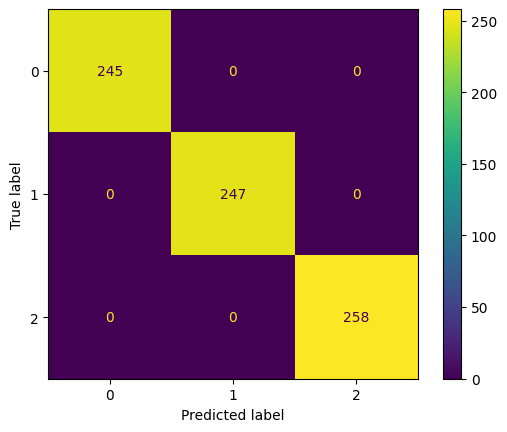

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay
print("Accuracy:", accuracy_score(y_test, ypred))
print(classification_report(y_test, ypred))
ConfusionMatrixDisplay.from_estimator(model, x_test, y_test)
plt.show()